# ARIMA: An End-to-End Implementation

This notebook presents a complete ARIMA modelling procedure applied to a simulated series with known parameters. This controlled setting enables direct assessment of the method's ability to recover the true data-generating process.

We implement the full ARIMA workflow: variance stabilisation via logarithmic transformation, differencing to achieve stationarity, identification of AR and MA orders, model fitting, validation, backtesting, and forecasting. The implementation relies solely on NumPy and SciPy.

**Execution.** The repository does not include a dedicated environment for `lessons/`. The notebook requires only a minimal set of packages; `statsmodels` and `statsforecast` appear solely in the final section for validation purposes:

```
uv run --with numpy,scipy,matplotlib,statsmodels,statsforecast,jupyter jupyter lab topics/forecasting/lessons/arima.ipynb
```

**Data-generating process.** The series is simulated with predetermined parameters. This deliberate choice allows us to evaluate the modelling procedure against a known benchmark, where the true $(p, d, q)$ orders and coefficients are specified a priori.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import toeplitz
from scipy.optimize import minimize
from scipy.stats import chi2
import statsmodels.api as sm
from statsforecast.models import AutoARIMA

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})

INK, ACCENT, MUTED = "#1f2933", "#b4522d", "#8a94a6"

## The Data-Generating Process

The series is generated from an ARIMA(1,1,1) process with drift **on the log scale**:

$$(1 - \phi B)\,\nabla \log y_t = c + (1 + \theta B)\,\varepsilon_t$$

Consequently, the level $y_t$ exhibits exponential growth with multiplicative noise. The logarithmic transformation is applied in this case to stabilise variance. The true parameter values are: $\phi = 0.6$, $\theta = 0.4$, $c = 0.004$, and $\sigma = 0.03$. The mean of the differenced log series is $c/(1-\phi) = 0.01$, corresponding to approximately 1% growth per period. The series represents 22 years of monthly observations (264 data points).

### Implications for $y_t$

Define $w_t = \log y_t$ and $z_t = \nabla w_t = w_t - w_{t-1}$. The governing equation constrains $z_t$; to obtain $y_t$, we must reverse the differencing operation and then exponentiate.

**Recursive representation.** Expanding $(1 - \phi B)z_t = c + (1 + \theta B)\varepsilon_t$ yields

$$z_t = c + \phi z_{t-1} + \varepsilon_t + \theta\varepsilon_{t-1}$$
$$\qquad\qquad y_t = y_{t-1}\,e^{z_t}$$

Here, $z_t$ represents the log-growth rate, and $e^{z_t}$ is the corresponding growth factor: each period multiplies the level by this factor. This recursive form underlies the `simulate` function implementation.

**Recursive representation in levels.** The operators $(1 - \phi B)$ and $\nabla = (1 - B)$ combine as follows: $(1 - \phi B)(1 - B) = 1 - (1+\phi)B + \phi B^2$, which yields

$$\log y_t = c + (1+\phi)\log y_{t-1} - \phi\log y_{t-2} + \varepsilon_t + \theta\varepsilon_{t-1}$$

$$y_t = e^{c}\;y_{t-1}^{\,1+\phi}\;y_{t-2}^{\,-\phi}\;e^{\,\varepsilon_t + \theta\varepsilon_{t-1}}.$$

Thus, the level at time $t$ is expressed as a product of powers of its own past values at $t-1$ and $t-2$. This multiplicative structure is linearised by the logarithmic transformation.

**Explicit solution.** The recursive forms above reference the series' own past and serve to illustrate its temporal evolution. Our objective is to derive an explicit formula for $y_t$: an explicit trend component multiplied by an explicit weighted sum of all shocks accumulated to date. We begin from the operator form

$$(1 - \phi B)\,z_t = c + (1 + \theta B)\,\varepsilon_t.$$

**(1) Inverting the AR operator.** Given $|\phi| < 1$, the series $\sum_{k\ge0}\phi^k B^k$ converges and serves as the inverse of $(1 - \phi B)$ — a consequence of the geometric series identity $1/(1-x) = \sum_k x^k$ with the lag operator $B$ substituting for $x$. Dividing by $(1 - \phi B)$ isolates $z_t$ into two components:

$$z_t \;=\; \underbrace{\frac{c}{1 - \phi B}}_{\text{deterministic}} \;+\; \underbrace{\frac{1 + \theta B}{1 - \phi B}}_{\text{stochastic}}\,\varepsilon_t.$$

**(2) The deterministic component.** Since lagging a constant leaves it unchanged ($B^k c = c$), the inverse operator acts on $c$ through simple multiplication by $\sum_k \phi^k$:

$$\frac{c}{1-\phi B} \;=\; \sum_{k\ge0}\phi^k B^k c \;=\; c\sum_{k\ge0}\phi^k \;=\; \frac{c}{1-\phi} \;=:\; \mu.$$

**(3) The stochastic component.** Expanding the product and collecting powers of $B$:

$$\frac{1+\theta B}{1-\phi B} \;=\; (1+\theta B)\sum_{k\ge0}\phi^k B^k \;=\; \sum_{k\ge0}\phi^k B^k \;+\; \theta\sum_{k\ge0}\phi^k B^{k+1}.$$

The coefficient $B^0$ appears only in the first sum with weight $1$. For $j \ge 1$, $B^j$ appears in the first sum with coefficient $\phi^j$ and in the second sum (at $k = j-1$) with coefficient $\theta\phi^{\,j-1}$. Defining $\psi_j$ as the coefficient of $B^j$,

$$\psi_0 = 1, \qquad \psi_j = \phi^j + \theta\phi^{\,j-1} = (\phi+\theta)\,\phi^{\,j-1} \quad (j \ge 1).$$

Substituting these expressions, we find that the growth rate equals its unconditional mean plus a weighted sum of all past shocks, with coefficients that decay geometrically at rate $\phi$:

$$z_t = \mu + \sum_{j\ge0}\psi_j\,\varepsilon_{t-j}.$$

**Reversing the differencing operation.** Since $z_s = w_s - w_{s-1}$, summing over $s$ telescopes: $\sum_{s=1}^{t} z_s = w_t - w_0$. Rearranging and substituting the expression for each $z_s$ — noting that $\mu$ appears once per period, yielding $\mu t$:

$$w_t \;=\; \log y_0 \;+\; \mu t \;+\; \sum_{s=1}^{t}\;\sum_{j\ge0}\psi_j\,\varepsilon_{s-j}.$$

**Interchanging the order of summation.** For a single shock $\varepsilon_k$, we sum its contributions across periods: $\varepsilon_k$ enters the $s$-th term with weight $\psi_{s-k}$ for every $s$ from $k$ to $t$. Its cumulative weight is

$$\Psi_{t-k} \;=\; \sum_{j=0}^{t-k}\psi_j \qquad\Longrightarrow\qquad \log y_t \;=\; \log y_0 + \mu t + \sum_{k \le t}\Psi_{t-k}\,\varepsilon_k.$$

**Exponentiating.** Applying the exponential function:

$$y_t \;=\; y_0\;e^{\mu t}\,\exp\Big(\sum_{k \le t}\Psi_{t-k}\,\varepsilon_k\Big).$$

**Evaluating $\Psi_m$.** This requires computing another geometric sum based on the expression for $\psi_j$:

$$\Psi_m = \sum_{j=0}^{m}\psi_j = 1 + (\phi+\theta)\sum_{j=1}^{m}\phi^{\,j-1}= 1 + (\phi+\theta)\frac{1-\phi^{m}}{1-\phi}\qquad\xrightarrow[\;m\to\infty\;]\qquad\Psi_\infty = 1 + \frac{\phi+\theta}{1-\phi} = \frac{1+\theta}{1-\phi}.$$

The expression for $y_t$ thus comprises an exponential trend $e^{\mu t}$ multiplied by accumulated noise, where the weight assigned to any single shock increases from $\Psi_0 = \psi_0 = 1$ upon impact to $\Psi_\infty$ once fully propagated. Three key implications follow:

- **Lognormal distribution.** Since $y_t = e^{\text{normal random variable}}$, the level $y_t$ follows a lognormal distribution. Consequently, exponentiating a forecast of $\log y$ yields the median level, not the mean.
- **Amplified permanent effects.** For the parameter values under consideration, $\Psi_\infty = 3.5$; thus, a one-time 1% shock to the growth rate ultimately translates to approximately a 3.6% change in the level.
- **Unbounded variance growth.** The variance of $\log y_t$ grows without bound because $\Psi_m$ converges to a non-zero constant rather than zero: every shock continues to influence the series indefinitely. This property causes the forecast interval of a differenced model to widen indefinitely rather than stabilise.

In [2]:
TRUE = {"phi": 0.6, "theta": 0.4, "c": 0.004, "sigma": 0.03}


def simulate(n=264, phi=0.6, theta=0.4, c=0.004, sigma=0.03, y0=100.0, seed=11, burn=200):
    """ARIMA(1,1,1) with drift in logs; returns the level series.

    n     — observations returned; 264 reads as 22 years of monthly data
    phi   — AR(1) coefficient: the share of last period's growth rate carried into this one
    theta — MA(1) coefficient: the share of last period's shock still felt in this one
    c     — drift; the mean log-growth is c/(1-phi) = 0.01, i.e. ~1% per period
    sigma — standard deviation of the shocks, on the log scale (multiplicative on y)
    y0    — starting level, the anchor the cumulated growth is applied to
    seed  — RNG seed, so the same draw of shocks comes back on every run
    burn  — extra observations simulated then discarded, so the series kept starts from
            the stationary distribution of z rather than from the arbitrary z_0 = 0
    """
    rng = np.random.default_rng(seed)
    eps = rng.normal(0.0, sigma, n + burn)
    z = np.zeros(n + burn)
    for t in range(1, n + burn):
        z[t] = c + phi * z[t - 1] + eps[t] + theta * eps[t - 1]
    return np.exp(np.log(y0) + np.cumsum(z[burn:]))


y = simulate()
t = np.arange(len(y))
print(f"T = {len(y)}    y[0] = {y[0]:.1f}    y[-1] = {y[-1]:.1f}")

T = 264    y[0] = 102.0    y[-1] = 5716.2


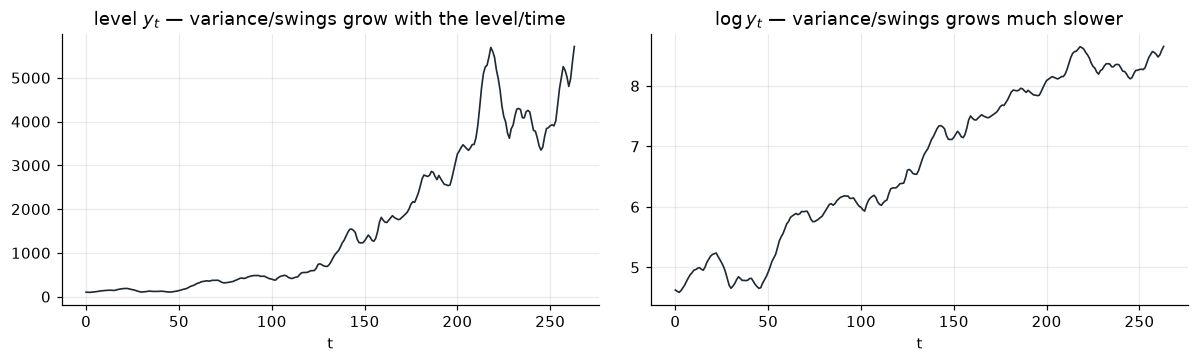

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(t, y, color=INK, lw=1.1)
axes[0].set_title("level $y_t$ — variance/swings grow with the level/time")
axes[1].plot(t, np.log(y), color=INK, lw=1.1)
axes[1].set_title(r"$\log y_t$ — variance/swings grows much slower")
for ax in axes:
    ax.set_xlabel("t")
fig.tight_layout()

## Step 1: Variance Stabilisation

The procedure `swings_scale_with_level(y)` implements this step. The series is partitioned into contiguous blocks; for each block, the mean and standard deviation are computed. A correlation test between block means and block standard deviations is then performed. A positive correlation indicates the presence of multiplicative noise, which the logarithmic transformation converts to additive noise. This transformation is essential because the ADF regression and all subsequent modelling steps assume shocks of constant variance. Moreover, since forecast intervals rely on a single variance estimate, stabilising the variance ensures that dispersion remains bounded as the series level increases.

corr(block mean, block sd) = 0.900  ->  log_recommended = True
after the log:               -0.346


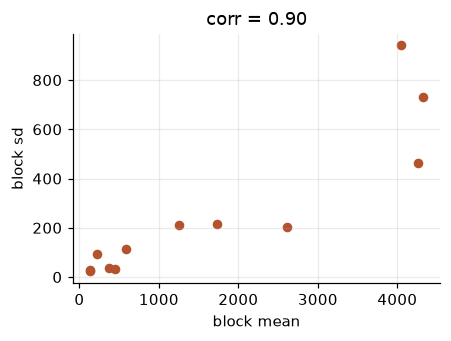

In [4]:
def swings_scale_with_level(x, n_blocks=12, threshold=0.6):
    """Do block standard deviations rise with block means? Then log."""
    blocks = np.array_split(np.asarray(x, float), n_blocks)
    means = np.array([b.mean() for b in blocks])
    sds = np.array([b.std(ddof=1) for b in blocks])
    corr = np.corrcoef(means, sds)[0, 1]
    return corr > threshold, means, sds, corr


# MacKinnon (1996), intercept-only case: cv(T) = b0 + b1/T + b2/T^2 + b3/T^3


log_recommended, means, sds, corr = swings_scale_with_level(y)
print(f"corr(block mean, block sd) = {corr:.3f}  ->  log_recommended = {log_recommended}")

y_work = np.log(y) if log_recommended else y.copy()

*_, corr_logged = swings_scale_with_level(y_work)
print(f"after the log:               {corr_logged:+.3f}")

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.scatter(means, sds, color=ACCENT, s=28)
ax.set(xlabel="block mean", ylabel="block sd", title=f"corr = {corr:.2f}")
fig.tight_layout()

## Step 2: Determining the Integration Order $d$ via the ADF Test

The parameter $d$ denotes the number of differencing operations required to render the series stationary. Each differencing operation removes one unit root. The core question at each iteration is whether the current series still contains a unit root; the augmented Dickey–Fuller (ADF) test provides the answer. The procedure applies differencing and repeats the test until stationarity is achieved.

Let $\phi(B)$ represent the autoregressive polynomial of the series. A unit root exists if $\phi(1) = 0$. The ADF test regresses the first difference $\nabla x_t$ on the lagged level $x_{t-1}$, including an intercept and $k$ lagged differences:

$$\nabla x_t = \alpha + \beta x_{t-1} + \sum_{j=1}^{k}\delta_j \nabla x_{t-j} + \varepsilon_t$$
$$\qquad \tau = \frac{\hat\beta}{\mathrm{SE}(\hat\beta)}.$$

Here, $\beta = -\phi(1)$, so the null hypothesis $H_0: \beta = 0$ corresponds precisely to the presence of a unit root, while the alternative $\beta < 0$ indicates stationarity. The $k$ lagged differences account for any remaining autoregressive structure, thereby isolating $\beta$ for testing; $\tau$ denotes the corresponding $t$-statistic.

The implementation incorporates three key design choices:

- **Lag selection via AIC.** The number of lags $k$ is chosen by minimising the AIC over $0 \le k \le \lfloor 12(T/100)^{1/4}\rfloor$ (Schwert's rule). All candidate regressions are fitted on the same observations to ensure comparable AIC values.
- **MacKinnon (1996) critical values.** Under the null hypothesis, the regressor $x_{t-1}$ follows a random walk, causing its variance to grow with $t$. This violates the standard $t$-ratio approximation and shifts the null distribution of $\tau$ to the left. The implementation therefore uses the critical values derived by MacKinnon (1996) rather than the standard normal distribution.
- **One-sided test at 5% significance.** Since stationarity corresponds to $\beta < 0$, the test rejects the null when $\tau$ falls below the critical value.

In [5]:
# MacKinnon (1996), intercept-only case: cv(T) = b0 + b1/T + b2/T^2 + b3/T^3
MACKINNON_C = {
    "1%": (-3.43035, -6.5393, -16.786, -79.433),
    "5%": (-2.86154, -2.8903, -4.234, -40.040),
    "10%": (-2.56677, -1.5384, -2.809, 0.0),
}


def ols(X, y):
    """Coefficients, their standard errors, and residuals."""
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    n, k = X.shape
    s2 = resid @ resid / (n - k)
    se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    return beta, se, resid


def adf_design(x, k, start):
    """Rows of the ADF regression: [1, x_{t-1}, dx_{t-1}, ..., dx_{t-k}] against dx_t."""
    dx = np.diff(x)
    rows = np.arange(start, len(dx))
    cols = [np.ones(len(rows)), x[rows]] + [dx[rows - j] for j in range(1, k + 1)]
    return np.column_stack(cols), dx[rows]


def adf_test(x, max_lag=None):
    x = np.asarray(x, float)
    T = len(x)
    if max_lag is None:
        max_lag = int(12 * (T / 100) ** 0.25)
    max_lag = min(max_lag, (T - 4) // 3)

    best_aic, k_star = np.inf, 0
    for k in range(max_lag + 1):                      # common sample -> comparable AICs
        X, dy = adf_design(x, k, max_lag)
        _, _, resid = ols(X, dy)
        aic = len(dy) * np.log(resid @ resid / len(dy)) + 2 * X.shape[1]
        if aic < best_aic:
            best_aic, k_star = aic, k

    X, dy = adf_design(x, k_star, k_star)             # refit at k* on the longest sample
    beta, se, _ = ols(X, dy)
    crit = {q: b[0] + b[1] / T + b[2] / T**2 + b[3] / T**3 for q, b in MACKINNON_C.items()}
    tau = beta[1] / se[1]
    return {"tau": tau, "lags": k_star, "crit": crit, "reject_5pct": bool(tau < crit["5%"])}

In [6]:
MAX_D = 2

z = y_work.copy()
d = 0
while True:
    r = adf_test(z)
    mark = "reject H0 -> stationary" if r["reject_5pct"] else "cannot reject H0 -> unit root"
    print(f"d = {d}:  tau = {r['tau']:+7.3f}   k = {r['lags']}   "
          f"5% crit = {r['crit']['5%']:.3f}   {mark}")
    if r["reject_5pct"] or d >= MAX_D:
        break
    z = np.diff(z)
    d += 1

print(f"\nd = {d}")

d = 0:  tau =  -0.668   k = 4   5% crit = -2.873   cannot reject H0 -> unit root
d = 1:  tau =  -6.788   k = 3   5% crit = -2.873   reject H0 -> stationary

d = 1


The ADF test cannot reject the unit root hypothesis for the log-level series; however, the first-differenced series is decisively stationary. The estimated integration order is therefore $d = 1$, which matches the true data-generating process.

## Step 3: Identifying the AR and MA Orders $p$ and $q$

### Diagnostic Plots

With $d$ established, the differenced series is stationary. The next step is to determine the number of autoregressive (AR) and moving-average (MA) terms. Both orders are inferred from the correlation structure between the series and its own past, as AR and MA terms leave distinct signatures in the autocorrelation function.

**Autocorrelation Function (ACF).** The sample autocorrelation $\hat\rho_k$ measures the correlation between $z_t$ and $z_{t-k}$. It accounts for all paths from $t-k$ to $t$, whether direct or through intermediate lags. For an MA($q$) process, $\hat\rho_k \approx 0$ for all $k > q$; the ACF exhibits a *cut-off* at lag $q$. In contrast, an AR process produces an ACF that decays gradually rather than cutting off abruptly.

**Partial Autocorrelation Function (PACF).** The partial autocorrelation at lag $k$ is the coefficient on $z_{t-k}$ in the regression of $z_t$ on $z_{t-1}, \dots, z_{t-k}$; it represents the correlation that remains after accounting for the intermediate lags. For an AR($p$) process, $\hat\phi_{kk} \approx 0$ for all $k > p$; the PACF exhibits a cut-off at lag $p$. An MA term, however, can only be approximated by an infinite AR process in this regression framework, resulting in a PACF that decays gradually. The PACF is computed here by solving the $k \times k$ Yule–Walker equations derived from the sample autocorrelations for each $k$.

**Confidence bands.** A bar is considered statistically indistinguishable from zero if it could plausibly arise from white noise. Under the white noise null hypothesis, $\hat\rho_k \sim N(0, 1/T)$, so the 95% confidence band is $\pm 2/\sqrt{T}$. Any bar falling within this band is treated as zero. The same band applies to the PACF.

**Interpretation.** Joint consideration of both functions yields the following identification rules: a PACF cut-off at $p$ with a decaying ACF indicates an AR($p$) process; an ACF cut-off at $q$ with a decaying PACF indicates an MA($q$) process; when both functions decay gradually, the process is ARMA with $p, q \ge 1$.

bands = +/-0.123
acf  [ 0.716  0.36   0.159  0.037 -0.013 -0.007]
pacf [ 0.716 -0.313  0.1   -0.098  0.05   0.011]


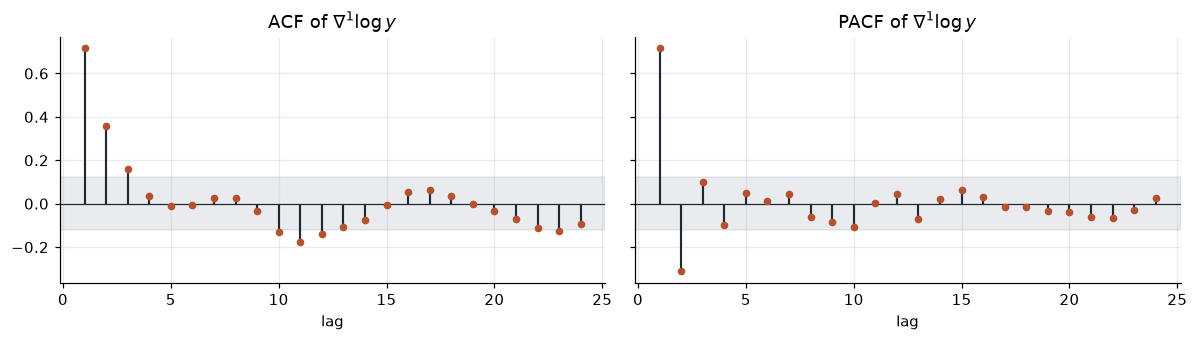

In [7]:
def sample_acf(x, nlags):
    x = np.asarray(x, float) - np.mean(x)
    denom = x @ x
    return np.array([1.0] + [x[k:] @ x[:-k] / denom for k in range(1, nlags + 1)])


def sample_pacf(x, nlags):
    r = sample_acf(x, nlags)
    out = [1.0]
    for k in range(1, nlags + 1):
        phi = np.linalg.solve(toeplitz(r[:k]), r[1:k + 1])   # Yule-Walker at order k
        out.append(phi[-1])
    return np.array(out)


def plot_bars(ax, values, band, title):
    lags = np.arange(1, len(values))
    ax.axhspan(-band, band, color=MUTED, alpha=0.18)
    ax.vlines(lags, 0, values[1:], color=INK, lw=1.4)
    ax.scatter(lags, values[1:], color=ACCENT, s=16, zorder=3)
    ax.axhline(0, color=INK, lw=0.8)
    ax.set(title=title, xlabel="lag")


NLAGS = 24


band = 2 / np.sqrt(len(z))
acf_z, pacf_z = sample_acf(z, NLAGS), sample_pacf(z, NLAGS)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
plot_bars(axes[0], acf_z, band, rf"ACF of $\nabla^{{{d}}}\log y$")
plot_bars(axes[1], pacf_z, band, rf"PACF of $\nabla^{{{d}}}\log y$")
fig.tight_layout()

print(f"bands = +/-{band:.3f}")
print("acf ", np.round(acf_z[1:7], 3))
print("pacf", np.round(pacf_z[1:7], 3))

Neither plot exhibits a cut-off: the ACF decays geometrically, and the PACF — characterised by a large first bar, a sizeable negative second bar, followed by gradual decay — also fades. This pattern corresponds to the mixed case in the identification table: both functions decaying indicates an ARMA($p,q$) process with $p, q \ge 1$.

### The Over-Differencing Check

The ADF test may over-difference: it has low power near a unit root and may fail to reject the null for a series that is actually stationary. An additional differencing operation introduces a signature in the ACF: $\hat\rho_1 \approx -1/2$ with no significant autocorrelations beyond lag 1. The appropriate response is to reduce $d$ rather than adding an MA(1) term; absorbing this signature would require $\theta = -1$, which corresponds to a unit root in the MA polynomial and renders the process non-invertible and thus unestimable. The over-differencing guard is applied before the model selection grid to prevent the grid from attempting to fit such non-invertible models.

In [8]:
def over_differenced(acf, band, d, tol=0.1):
    """Lag-1 near -0.5 and nothing beyond it: the signature of one difference too many."""
    return d > 0 and abs(acf[1] + 0.5) < tol and np.all(np.abs(acf[2:]) < band)


print("over-differenced:", over_differenced(acf_z, band, d))
print(f"  rho_1 = {acf_z[1]:+.3f}   (the tell would be near -0.500)")

over-differenced: False
  rho_1 = +0.716   (the tell would be near -0.500)


### Fitting by Conditional Sum of Squares

For a candidate ARMA($p,q$) model, the unknown parameters are $c$, $\phi_1, \dots, \phi_p$ and $\theta_1, \dots, \theta_q$. Given trial parameter values, the shocks are obtained from the data via the model equation solved for $\varepsilon_t$:

$$\varepsilon_t = z_t - c - \sum_{i=1}^{p}\phi_i z_{t-i} - \sum_{j=1}^{q}\theta_j\varepsilon_{t-j},$$

generated recursively from $\varepsilon = 0$ before the first observation — the *conditional* aspect of the method: presample shocks are set to their unconditional expectation of zero rather than estimated.

Under the assumption of normally distributed shocks, the log-likelihood of these residuals is

$$\ell = -\tfrac{T}{2}\log(2\pi\sigma^2) - \tfrac{1}{2\sigma^2}S, \qquad S = \sum_t \varepsilon_t^2.$$

For any fixed $\sigma^2$, $\ell$ decreases as $S$ increases, so maximising $\ell$ over $(c, \phi, \theta)$ is equivalent to minimising $S$. Maximising over $\sigma^2$ then yields $\hat\sigma^2 = S/T$ and $\ell = -\tfrac{T}{2}(\log 2\pi\hat\sigma^2 + 1)$, the value used by AIC.

The minimisation of $S$ depends on $q$. When $q = 0$, the residuals are linear in the parameters and $S$ has a closed-form least-squares solution. When $q > 0$, the recursion causes each residual to depend on the previous residuals, making $\varepsilon_t$ a polynomial of degree $t-1$ in $\theta$. Consequently, `scipy.optimize.minimize` is employed for numerical minimisation.

The search is constrained to the admissible region by returning an arbitrarily large $S$ outside it: all roots of $\phi(B)$ must lie outside the unit circle (stationarity condition), and all roots of $\theta(B)$ must likewise lie outside the unit circle (invertibility condition). The invertibility constraint is particularly important for this method: the error introduced by starting with $\varepsilon = 0$ propagates as $(-\theta)^t$ and dies out only if $|\theta| < 1$.

Every candidate model is fitted on the **same rows**: the first `START` observations are withheld for all models to ensure that the log-likelihood values compared by the grid are based on identical data subsets.

In [9]:
def min_root_modulus(ascending):
    """Smallest |root| of the polynomial given by ascending coefficients."""
    if len(ascending) == 1:
        return np.inf
    return np.min(np.abs(np.roots(ascending[::-1])))


def is_stationary(phi):
    return min_root_modulus(np.concatenate(([1.0], -np.asarray(phi, float)))) > 1 + 1e-8


def is_invertible(theta):
    return min_root_modulus(np.concatenate(([1.0], np.asarray(theta, float)))) > 1 + 1e-8


def unpack(params, p, q):
    return params[0], params[1:1 + p], params[1 + p:1 + p + q]


def css_residuals(x, params, p, q, start):
    """Roll the shock recursion forward from eps = 0; return residuals from `start` on."""
    c, phi, theta = unpack(params, p, q)
    e = np.zeros(len(x))
    for k in range(start, len(x)):
        pred = c
        for i in range(p):
            pred += phi[i] * x[k - 1 - i]
        for j in range(q):
            pred += theta[j] * e[k - 1 - j]      # e is still 0 before `start`
        e[k] = x[k] - pred
    return e[start:]


def fit_arma(x, p, q, start):
    x = np.asarray(x, float)
    n_eff = len(x) - start

    def sum_of_squares(params):
        _, phi, theta = unpack(params, p, q)
        if not (is_stationary(phi) and is_invertible(theta)):
            return 1e12
        e = css_residuals(x, params, p, q, start)
        return float(e @ e)

    x0 = np.concatenate(([x.mean() * (1 - 0.5 * p)], np.full(p, 0.1), np.full(q, 0.1)))
    res = minimize(sum_of_squares, x0, method="Nelder-Mead",
                   options={"maxiter": 4000, "xatol": 1e-8, "fatol": 1e-10})
    res = minimize(sum_of_squares, res.x, method="Nelder-Mead",
                   options={"maxiter": 4000, "xatol": 1e-10, "fatol": 1e-12})

    c, phi, theta = unpack(res.x, p, q)
    resid = css_residuals(x, res.x, p, q, start)
    S = float(resid @ resid)
    sigma2 = S / n_eff
    loglike = -0.5 * n_eff * (np.log(2 * np.pi * sigma2) + 1.0)
    n_params = p + q + 2                          # AR, MA, intercept, sigma^2
    return {"p": p, "q": q, "c": c, "phi": np.asarray(phi), "theta": np.asarray(theta),
            "resid": resid, "S": S, "sigma2": sigma2, "loglike": loglike,
            "aic": -2 * loglike + 2 * n_params, "nobs": n_eff, "start": start}

A verification of the implementation is warranted before proceeding. The lesson derives the AR(1) least-squares estimator in closed form,

$$\hat\phi = \frac{\sum_t y_t y_{t-1}}{\sum_t y_{t-1}^2},$$

and demonstrates its equivalence to the lag-1 sample autocorrelation, subject to end effects. The optimisation routine should converge to the same value.

In [10]:
centred = z - z.mean()
phi_closed_form = (centred[1:] @ centred[:-1]) / (centred[:-1] @ centred[:-1])
phi_optimiser = fit_arma(z, 1, 0, start=1)["phi"][0]

print(f"boxed least-squares formula : {phi_closed_form:.6f}")
print(f"CSS optimiser               : {phi_optimiser:.6f}")
print(f"lag-1 sample autocorrelation: {sample_acf(z, 1)[1]:.6f}")

boxed least-squares formula : 0.718838
CSS optimiser               : 0.718861
lag-1 sample autocorrelation: 0.715909


### Model Selection via AIC

Every $(p, q)$ combination up to `MAX_P` and `MAX_Q` is fitted, and the competing models are compared using the Akaike Information Criterion (AIC):

$$\mathrm{AIC} = -2\ell + 2k, \qquad k = p + q + 2,$$

where $k$ denotes the number of fitted parameters, including $c$ and $\sigma^2$. Adding a term can only increase $\ell$, so the $2k$ penalty prevents the largest model from always being selected; it effectively charges each parameter two units of $-2\ell$, and a term is retained only if it improves the fit by more than this cost.

Candidates are evaluated in order of increasing $p + q$, and a larger model replaces the incumbent only if it improves the AIC by more than `TOL`. When the AIC improvement falls within `TOL`, the models are treated as equivalent, and the tie is resolved in favour of the more parsimonious model.

In [11]:
MAX_P, MAX_Q, TOL = 3, 3, 1.0


START = MAX_P                                    # identical rows for every candidate


def select_order(x, rejected=frozenset(), max_p=MAX_P, max_q=MAX_Q, tol=TOL, start=START):
    aics, best_aic, best = {}, np.inf, None
    order_of_visit = sorted(
        ((i, j) for i in range(max_p + 1) for j in range(max_q + 1) if (i, j) not in rejected),
        key=lambda ij: (ij[0] + ij[1], ij[0], ij[1]),
    )
    for i, j in order_of_visit:
        aics[(i, j)] = fit_arma(x, i, j, start)["aic"]
        if aics[(i, j)] < best_aic - tol:
            best_aic, best = aics[(i, j)], (i, j)
    return best, aics


(p, q), aics = select_order(z)

header = "      " + "".join(f"   q={j}   " for j in range(MAX_Q + 1))
print(header)
for i in range(MAX_P + 1):
    row = "".join(f"{aics[(i, j)]:9.1f}" for j in range(MAX_Q + 1))
    print(f" p={i} {row}")
print(f"\nselected (p, q) = ({p}, {q})   AIC = {aics[(p, q)]:.2f}")

         q=0      q=1      q=2      q=3   
 p=0    -864.1  -1039.2  -1068.2  -1076.9
 p=1   -1051.4  -1080.2  -1078.2  -1077.1
 p=2   -1075.8  -1078.2  -1078.2  -1076.6
 p=3   -1076.2  -1076.5  -1076.7  -1075.0

selected (p, q) = (1, 1)   AIC = -1080.21


The grid search selects ARMA(1,1) for the differenced log series — equivalent to ARIMA(1,1,1) for $\log y$, which matches the true data-generating process. Notably, the pure AR and MA models are penalised by AIC: AR(3) and MA(3) each require three parameters to approximate what the mixed ARMA(1,1) model achieves with only two, with the truncated AR representation $\tilde\pi_j = (\phi+\theta)(-\theta)^{j-1}$ manifesting in the elevated AIC values.

## Steps 4 and 5: Model Fitting and Residual Diagnostics

For a correctly specified model, the residuals should be indistinguishable from white noise. Two diagnostic tests are applied, following the pseudocode: first, that every residual autocorrelation lies within Bartlett's confidence bands; second, that the Ljung–Box test statistic is non-significant over $m = 20$ lags, with degrees of freedom adjusted for the $p + q$ fitted coefficients.

The band check requires a multiplicity adjustment: at a 5% significance level for each lag, one excursion in 20 lags is expected by chance. Requiring all 20 autocorrelations to lie within the bands would reject correctly specified models approximately $1 - 0.95^{20} \approx 64\%$ of the time. The check therefore allows for the expected false-alarm rate.

In [12]:
M_LB = 20


def ljung_box(resid, m, dof):
    T = len(resid)
    r = sample_acf(resid, m)[1:]
    Q = T * (T + 2) * np.sum(r**2 / (T - np.arange(1, m + 1)))
    return Q, float(chi2.sf(Q, max(dof, 1)))


def residuals_are_white(resid, p, q, m=M_LB, alpha=0.05):
    band = 2 / np.sqrt(len(resid))
    r = sample_acf(resid, m)[1:]
    excursions = int(np.sum(np.abs(r) > band))
    acf_ok = excursions <= np.ceil(alpha * m)     # the expected false-alarm count
    Q, pvalue = ljung_box(resid, m, dof=m - p - q)
    return {"acf_ok": acf_ok, "excursions": excursions, "band": band,
            "Q": Q, "p": pvalue, "lb_ok": pvalue > alpha, "acf": r}


fit = fit_arma(z, p, q, START)
check = residuals_are_white(fit["resid"], p, q)

print(f"ARIMA({p},{d},{q}) on log y      fitted on {fit['nobs']} observations\n")
print(f"  c        = {fit['c']:+.5f}      implied mean of dz = c/(1-sum phi) = "
      f"{fit['c'] / (1 - fit['phi'].sum()):+.5f}   (true {TRUE['c'] / (1 - TRUE['phi']):+.5f})")
for i, v in enumerate(fit["phi"], 1):
    print(f"  phi_{i}    = {v:+.4f}       (true {TRUE['phi']:+.4f})")
for j, v in enumerate(fit["theta"], 1):
    print(f"  theta_{j}  = {v:+.4f}       (true {TRUE['theta']:+.4f})")
print(f"  sigma    = {np.sqrt(fit['sigma2']):.5f}       (true {TRUE['sigma']:.5f})")
print(f"  logLik   = {fit['loglike']:.2f}      AIC = {fit['aic']:.2f}")
def arma11_rho1(phi_, theta_):
    """Lag-1 autocorrelation of an ARMA(1,1) -- section 5.2's derivation, one step further."""
    return (1 + phi_ * theta_) * (phi_ + theta_) / (1 + 2 * phi_ * theta_ + theta_**2)


def mean_se(phi_, theta_, sigma, n):
    """SE of the sample mean: long-run variance sigma^2 (sum psi_j)^2, divided by n."""
    return np.sqrt(sigma**2 * ((1 + theta_) / (1 - phi_)) ** 2 / n)


if (p, q) == (1, 1):                              # closed forms available at this order
    print(f"\n  rho_1:  fitted {arma11_rho1(fit['phi'][0], fit['theta'][0]):.4f}   "
          f"sample {sample_acf(z, 1)[1]:.4f}   "
          f"population {arma11_rho1(TRUE['phi'], TRUE['theta']):.4f}")
    print(f"  se of the sample mean of dz: "
          f"{mean_se(TRUE['phi'], TRUE['theta'], TRUE['sigma'], len(z)):.5f}")
print(f"\n  residual ACF: {check['excursions']} excursion(s) beyond "
      f"+/-{check['band']:.3f} in {M_LB} lags -> acf_ok = {check['acf_ok']}")
print(f"  Ljung-Box:    Q = {check['Q']:.2f} on {M_LB - p - q} df, "
      f"p = {check['p']:.3f} -> lb_ok = {check['lb_ok']}")

ARIMA(1,1,1) on log y      fitted on 260 observations

  c        = +0.00769      implied mean of dz = c/(1-sum phi) = +0.01587   (true +0.01000)
  phi_1    = +0.5156       (true +0.6000)
  theta_1  = +0.4759       (true +0.4000)
  sigma    = 0.02985       (true 0.03000)
  logLik   = 544.11      AIC = -1080.21

  rho_1:  fitted 0.7190   sample 0.7159   population 0.7561
  se of the sample mean of dz: 0.00647

  residual ACF: 1 excursion(s) beyond +/-0.124 in 20 lags -> acf_ok = True
  Ljung-Box:    Q = 11.65 on 18 df, p = 0.865 -> lb_ok = True


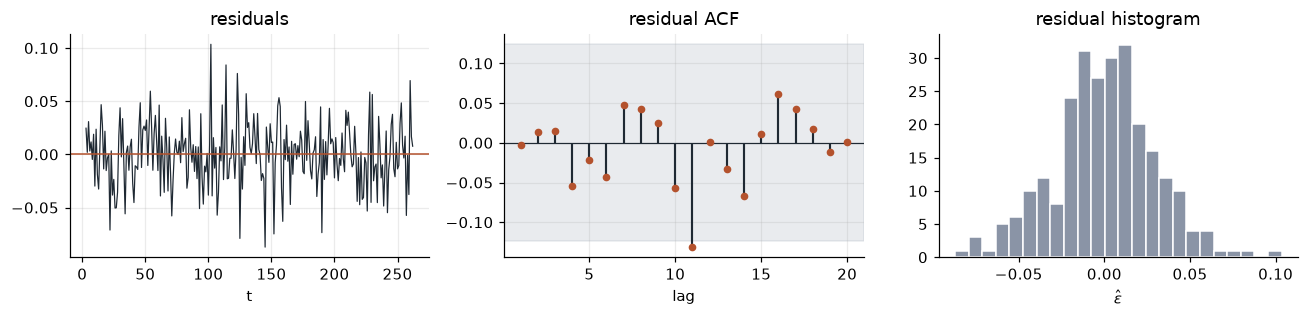

In [13]:
resid = fit["resid"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.0))
axes[0].plot(np.arange(START, START + len(resid)), resid, color=INK, lw=0.8)
axes[0].axhline(0, color=ACCENT, lw=1)
axes[0].set(title="residuals", xlabel="t")
plot_bars(axes[1], sample_acf(resid, M_LB), 2 / np.sqrt(len(resid)), "residual ACF")
axes[2].hist(resid, bins=24, color=MUTED, edgecolor="white")
axes[2].set(title="residual histogram", xlabel=r"$\hat\varepsilon$")
axes[2].grid(False)
fig.tight_layout()

The estimated shock standard deviation $\hat\sigma$ recovers the true value to within approximately 1%, the residual autocorrelations lie within the confidence bands (except for the single excursion expected by multiplicity), and the Ljung–Box statistic is far from significant: no remaining structure requires modelling.

The individual estimates $\hat\phi$ and $\hat\theta$ deviate further from their true values, in opposite directions. This discrepancy reflects the ARMA(1,1) identification trade-off rather than a poor fit: increasing $\phi$ while decreasing $\theta$ leaves the first-order autocorrelation

$$\rho_1 = \frac{(1+\phi\theta)(\phi+\theta)}{1+2\phi\theta+\theta^2}$$

largely unchanged, implying that the likelihood surface forms a long, shallow valley in this direction. The printed diagnostic confirms this behaviour: the pair's implied $\rho_1$ reproduces the sample $\hat\rho_1$, which is precisely what least squares estimates. The sample autocorrelation differs from its population counterpart by ordinary sampling variability, and the parameter estimates inherit this variation.

The drift parameter is the least precisely estimated, for a related reason: the mean of a highly persistent series has a standard error that is inflated by that persistence — the value is printed above — so a discrepancy of less than one standard error is unremarkable.

## Forecasting

The forecast of $z_{T+h}$ is its conditional expectation given the data up to time $T$ — the minimum mean squared error predictor. Computing this expectation through the model equation replaces each term with its known value at time $T$: future shocks with $0$, past shocks with their reconstructed residuals, and future values with their own forecasts.

$$\hat z_{T+h} = c + \sum_{i=1}^{p}\phi_i \hat z_{T+h-i} + \sum_{j=1}^{q}\theta_j\hat\varepsilon_{T+h-j}.$$

This recursion is applied for $h = 1, 2, \dots$, with each step utilising the forecasts from previous steps. The result is on the differenced scale; the level forecast follows by cumulative summation $d$ times, with each integration anchored on the last observed value at the corresponding differencing depth.

The forecast error $e_{T+h}$ — the difference between the realised value and its forecast on the given scale — comprises the future shocks $\varepsilon_{T+1}, \dots, \varepsilon_{T+h}$, each weighted by its propagation up to time $T+h$. These weights are the $\psi_j$ coefficients of the model on that scale; for the level, this corresponds to the **undifferenced** model, where $\psi(B) = \frac{\theta(B)}{\phi(B)(1-B)^d}$. Assuming independent shocks, the forecast error variance accumulates as:

$$\mathrm{Var}(e_{T+h}) = \sigma^2\sum_{j=0}^{h-1}\psi_j^2.$$

The $(1-B)^d$ term in the denominator explains why the prediction interval of an integrated model widens without bound: for a stationary model, the weights $\psi_j$ decay and the sum converges; however, $(1-B)^{-d}$ accumulates, so the $\psi_j$ approach a non-zero constant, and each additional forecast horizon adds approximately the same variance contribution.

In [14]:
def psi_weights(phi, theta, d, n):
    """Impulse weights of theta(B) / [phi(B) (1-B)^d]."""
    from numpy.polynomial.polynomial import polymul

    ar = np.concatenate(([1.0], -np.asarray(phi, float)))
    for _ in range(d):
        ar = polymul(ar, [1.0, -1.0])            # multiply in one (1 - B)
    a = -ar[1:]                                  # y_t = sum_i a_i y_{t-i} + shocks
    th = np.asarray(theta, float)

    psi = np.zeros(n)
    psi[0] = 1.0
    for j in range(1, n):
        s = sum(a[i] * psi[j - 1 - i] for i in range(min(len(a), j)))
        if j <= len(th):
            s += th[j - 1]
        psi[j] = s
    return psi


def forecast_arma(x, fit, h):
    """Conditional-expectation recursion on the stationary (differenced) series."""
    xs = list(np.asarray(x, float))
    es = list(np.zeros(fit["start"])) + list(fit["resid"])
    out = []
    for _ in range(h):
        v = fit["c"]
        for i in range(fit["p"]):
            v += fit["phi"][i] * xs[-1 - i]
        for j in range(fit["q"]):
            v += fit["theta"][j] * es[-1 - j]
        xs.append(v)
        es.append(0.0)                           # a shock not yet drawn has expectation 0
        out.append(v)
    return np.array(out)


def forecast_arima(series, fit, d, h):
    """Forecasts on the scale of `series`, with the variance of the forecast error."""
    x = np.diff(series, n=d) if d else np.asarray(series, float)
    level = forecast_arma(x, fit, h)
    for k in range(d, 0, -1):                    # integrate back, one difference at a time
        anchor = np.diff(series, n=k - 1)[-1]
        level = anchor + np.cumsum(level)
    var = fit["sigma2"] * np.cumsum(psi_weights(fit["phi"], fit["theta"], d, h) ** 2)
    return level, var

## Step 6: Backtesting Against the Naive Forecast

In-sample diagnostics validate model adequacy for the observed data. Forecasting performance, however, requires out-of-sample evidence: fit the model on $y_1,\dots,y_n$, forecast horizons $n+1 \dots n+h$, compare predictions against realised values, advance the forecast origin, and repeat. The naive benchmark $\hat y_{n+h} = y_n$ is optimal under a random walk hypothesis; outperforming this benchmark demonstrates that the series contains structure beyond a unit root.

In [15]:
H_BACKTEST, WIDTH, STEP = 6, 96, 4


def rmse(errors):
    return np.sqrt(np.mean(np.array(errors) ** 2, axis=0))


def rolling_origin(series, order, origins, h, start=START):
    p_, d_, q_ = order
    model_err, naive_err = [], []
    for n in origins:
        train = series[:n]
        x = np.diff(train, n=d_) if d_ else train
        f, _ = forecast_arima(train, fit_arma(x, p_, q_, start), d_, h)
        actual = series[n:n + h]
        model_err.append(actual - f[:len(actual)])
        naive_err.append(actual - train[-1])     # flat at the last observation
    return rmse(model_err), rmse(naive_err)


origins = list(range(len(y_work) - WIDTH, len(y_work) - H_BACKTEST, STEP))
rmse_model, rmse_naive = rolling_origin(y_work, (p, d, q), origins, H_BACKTEST)

print(f"{len(origins)} origins, horizons 1..{H_BACKTEST}, RMSE on the log scale\n")
print("  h      model      naive    ratio")
for i in range(H_BACKTEST):
    print(f"  {i + 1}    {rmse_model[i]:7.4f}    {rmse_naive[i]:7.4f}    "
          f"{rmse_model[i] / rmse_naive[i]:5.2f}")
beats_naive = rmse_model.mean() < rmse_naive.mean()
print(f"\n  mean {rmse_model.mean():7.4f}    {rmse_naive.mean():7.4f}    "
      f"{rmse_model.mean() / rmse_naive.mean():5.2f}   beats naive: {beats_naive}")

23 origins, horizons 1..6, RMSE on the log scale

  h      model      naive    ratio
  1     0.0227     0.0422     0.54
  2     0.0571     0.0769     0.74
  3     0.0769     0.1014     0.76
  4     0.1083     0.1297     0.83
  5     0.1400     0.1584     0.88
  6     0.1575     0.1807     0.87

  mean  0.0937     0.1149     0.82   beats naive: True


The model outperforms the naive benchmark at every horizon, with the performance margin diminishing as the horizon increases — a direct consequence of the forecast recursion. The AR memory decays as $\phi^h$, with a time constant of approximately $1/(1-\hat\phi) \approx 2$ periods; beyond this point, the forecast consists primarily of the drift component, and the advantage over a flat-line forecast reduces to the benefit conferred by the drift alone.

## Step 7: Forecast Construction and Prediction Intervals

The point forecast is computed as the conditional expectation, with the 95% prediction interval given by $\pm 2\sqrt{\mathrm{Var}(e_{T+h})}$, then transformed via the exponential function back to the level scale. Since the exponential function is monotonic, the interval endpoints transform directly; the resulting point forecast corresponds to the median of the level distribution, not its mean.

In [16]:
H = 24

f_log, var_log = forecast_arima(y_work, fit, d, H)
lo_log, hi_log = f_log - 2 * np.sqrt(var_log), f_log + 2 * np.sqrt(var_log)

forecasts, lo, hi = (np.exp(f_log), np.exp(lo_log), np.exp(hi_log)) if log_recommended else \
                    (f_log, lo_log, hi_log)

print("  h      forecast          95% interval        width/forecast")
for i in [0, 2, 5, 11, 23]:
    print(f"  {i + 1:2d}    {forecasts[i]:9.1f}    [{lo[i]:8.1f}, {hi[i]:8.1f}]    "
          f"{(hi[i] - lo[i]) / forecasts[i]:6.1%}")

  h      forecast          95% interval        width/forecast
   1       5970.2    [  5624.2,   6337.5]     11.9%
   3       6297.2    [  5155.5,   7691.7]     40.3%
   6       6649.0    [  4644.2,   9519.2]     73.3%
  12       7321.0    [  4137.9,  12952.8]    120.4%
  24       8857.2    [  3785.9,  20722.0]    191.2%


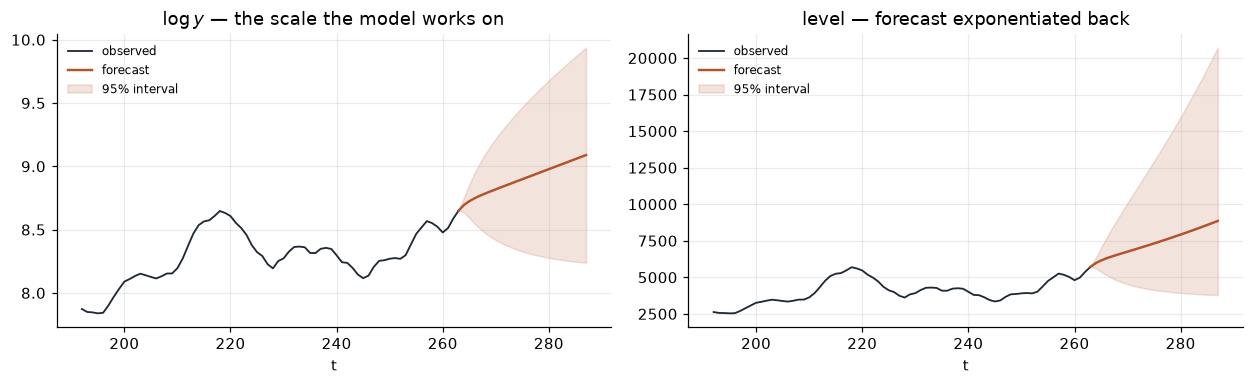

In [17]:
future = np.arange(len(y) - 1, len(y) + H)     # start at the last observation, no gap
tail = slice(len(y) - 72, None)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
for ax, obs, pt, band_lo, band_hi, title in [
    (axes[0], y_work, f_log, lo_log, hi_log, r"$\log y$ — the scale the model works on"),
    (axes[1], y, forecasts, lo, hi, "level — forecast exponentiated back"),
]:
    anchored = [np.concatenate(([obs[-1]], v)) for v in (pt, band_lo, band_hi)]
    ax.plot(t[tail], obs[tail], color=INK, lw=1.2, label="observed")
    ax.plot(future, anchored[0], color=ACCENT, lw=1.6, label="forecast")
    ax.fill_between(future, anchored[1], anchored[2], color=ACCENT, alpha=0.16,
                    label="95% interval")
    ax.set(title=title, xlabel="t")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()

The prediction interval widens without bound — a characteristic signature of $d = 1$ integration. Unlike a stationary process, where the forecast variance eventually saturates at the series variance, the differenced model's forecast of the *level* accumulates every future shock with weight $\psi_j \to (1+\theta)/(1-\phi)$. Since these weights approach a non-zero constant rather than decaying, each additional forecast horizon adds approximately the same variance contribution, causing the interval to expand indefinitely. On the level scale, the same interval is asymmetric: a symmetric interval in logarithms corresponds to a multiplicative interval in levels.

## Cross-Validation Against Established Libraries

Both libraries parameterise the drift as the mean of $\nabla \log y$, i.e., $\mu = c/(1-\phi)$, whereas `fit_arma` reports the intercept $c$; the comparison tables therefore convert between these parameterisations. Both libraries maximise the exact likelihood via a state-space filter, utilising all observations and integrating out the presample shocks; by contrast, `fit_arma` minimises the conditional sum of squares with `START` rows withheld and presample shocks set to zero. Consequently, the log-likelihoods are not directly comparable, and the coefficient estimates should agree closely but not identically.

### statsmodels — Specified Order

The `statsmodels` library is provided with the true model specification: ARIMA(1,1,1) with drift on $\log y$.

In [18]:
def compare(name, params, mean_log, lo_log, hi_log):
    """fit_arma against a library fit: coefficients, then forecasts on the level scale."""
    ours = {"mu": fit["c"] / (1 - fit["phi"].sum()), "phi": fit["phi"][0],
            "theta": fit["theta"][0], "sigma": np.sqrt(fit["sigma2"])}
    true = {"mu": TRUE["c"] / (1 - TRUE["phi"]), "phi": TRUE["phi"], "theta": TRUE["theta"],
            "sigma": TRUE["sigma"]}
    print(f"{'':8}{'fit_arma (CSS)':>16}{name:>16}{'true':>10}")
    for k in ours:
        print(f"  {k:6}{ours[k]:16.5f}{params[k]:16.5f}{true[k]:10.5f}")
    mean, lo_, hi_ = np.exp(mean_log), np.exp(lo_log), np.exp(hi_log)
    print(f"\n{'h':>4}{'forecast':>23}{'95% interval':>35}")
    print(f"{'':4}{'fit_arma':>11}{name:>14}{'fit_arma':>19}{name:>20}")
    for i in [0, 5, 11, 23]:
        print(f"{i + 1:4d}{forecasts[i]:11.1f}{mean[i]:14.1f}"
              f"  [{lo[i]:7.1f}, {hi[i]:7.1f}]  [{lo_[i]:7.1f}, {hi_[i]:7.1f}]")
    print(f"\n  max |difference| in point forecasts, h = 1..{H}: "
          f"{np.abs(forecasts / mean - 1).max():.2%} of the level")


sm_fit = sm.tsa.arima.ARIMA(y_work, order=(p, d, q), trend="t").fit()
sm_fc = sm_fit.get_forecast(H)
sm_ci = sm_fc.conf_int(alpha=0.05)

print(f"loglik  fit_arma {fit['loglike']:.2f} on {fit['nobs']} rows   "
      f"statsmodels {sm_fit.llf:.2f} on {sm_fit.nobs} rows   (not comparable, see above)\n")
compare("statsmodels",
        {"mu": sm_fit.params[0], "phi": sm_fit.arparams[0], "theta": sm_fit.maparams[0],
         "sigma": np.sqrt(sm_fit.params[-1])},
        sm_fc.predicted_mean, sm_ci[:, 0], sm_ci[:, 1])

loglik  fit_arma 544.11 on 260 rows   statsmodels 550.88 on 264 rows   (not comparable, see above)

          fit_arma (CSS)     statsmodels      true
  mu             0.01587         0.01536   0.01000
  phi            0.51557         0.50931   0.60000
  theta          0.47588         0.48205   0.40000
  sigma          0.02985         0.02973   0.03000

   h               forecast                       95% interval
       fit_arma   statsmodels           fit_arma         statsmodels
   1     5970.2        5969.0  [ 5624.2,  6337.5]  [ 5631.1,  6327.1]
   6     6649.0        6628.4  [ 4644.2,  9519.2]  [ 4677.1,  9393.7]
  12     7321.0        7275.4  [ 4137.9, 12952.8]  [ 4184.3, 12649.9]
  24     8857.2        8748.1  [ 3785.9, 20722.0]  [ 3840.7, 19926.0]

  max |difference| in point forecasts, h = 1..24: 1.25% of the level


### statsforecast — Automatic Model Selection

`AutoARIMA` implements the Hyndman–Khandakar procedure: KPSS tests determine $d$, followed by a stepwise search over $(p, q)$ and the drift term, with candidates scored by AICc. Each candidate model is fitted by exact maximum likelihood. The central question is whether an independent model identification procedure recovers the true data-generating order.

In [19]:
sf_fit = AutoARIMA(season_length=1).fit(y_work)
sf_p, sf_q, *_, sf_d, _ = sf_fit.model_["arma"]          # (p, q, P, Q, m, d, D)
sf_coef = sf_fit.model_["coef"]
sf_fc = sf_fit.predict(h=H, level=[95])

print(f"identified: ARIMA({sf_p},{sf_d},{sf_q}){' with drift' if 'drift' in sf_coef else ''}"
      f"   (the notebook found ARIMA({p},{d},{q}) with drift)")
print(f"loglik  {sf_fit.model_['loglik']:.2f} on {sf_fit.model_['nobs']} rows   "
      f"AICc {sf_fit.model_['aicc']:.2f}\n")
compare("statsforecast",
        {"mu": sf_coef.get("drift", np.nan), "phi": sf_coef.get("ar1", np.nan),
         "theta": sf_coef.get("ma1", np.nan), "sigma": np.sqrt(sf_fit.model_["sigma2"])},
        np.asarray(sf_fc["mean"]), np.asarray(sf_fc["lo-95"]), np.asarray(sf_fc["hi-95"]))

identified: ARIMA(1,1,1) with drift   (the notebook found ARIMA(1,1,1) with drift)
loglik  550.88 on 263 rows   AICc -1093.60

          fit_arma (CSS)   statsforecast      true
  mu             0.01587         0.01565   0.01000
  phi            0.51557         0.51348   0.60000
  theta          0.47588         0.47968   0.40000
  sigma          0.02985         0.02991   0.03000

   h               forecast                       95% interval
       fit_arma statsforecast           fit_arma       statsforecast
   1     5970.2        5969.9  [ 5624.2,  6337.5]  [ 5630.0,  6330.3]
   6     6649.0        6641.1  [ 4644.2,  9519.2]  [ 4669.6,  9444.9]
  12     7321.0        7302.5  [ 4137.9, 12952.8]  [ 4172.9, 12779.4]
  24     8857.2        8811.7  [ 3785.9, 20722.0]  [ 3829.4, 20276.5]

  max |difference| in point forecasts, h = 1..24: 0.52% of the level


## References

- Seabold, S. and Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92–96. This library underpins the first cross-validation exercise; `statsmodels.tsa.arima.model.ARIMA` fits a specified order by exact maximum likelihood through a state-space filter. [Documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.arima.model.ARIMA.html). License: BSD-3-Clause.
- Garza, F., Mergenthaler Canseco, M., Challú, C., and Olivares, K. G. (2022). *StatsForecast: Lightning fast forecasting with statistical and econometric models.* Nixtla. This library supports the second cross-validation exercise; `statsforecast.models.AutoARIMA` performs both order identification and estimation. [Repository](https://github.com/Nixtla/statsforecast). License: Apache-2.0.
- Hyndman, R. J. and Khandakar, Y. (2008). Automatic time series forecasting: the forecast package for R. *Journal of Statistical Software*, 27(3), 1–22. [doi:10.18637/jss.v027.i03](https://doi.org/10.18637/jss.v027.i03). This work describes the procedure that `AutoARIMA` implements: KPSS tests for $d$, with a stepwise search over $(p, q)$ scored by AICc.